# Lab: Credit Card Fraud Detection with Decision Trees and SVM

*This notebook demonstrates a complete data science workflow for a classification task, from data collection to model evaluation, using a real-world imbalanced dataset.*

---

## Stage 1: Business Understanding
Let's start by understanding the problem from a business perspective.

* **Scenario:** We are data scientists at a financial institution. Our task is to build a model that can identify fraudulent credit card transactions in real-time.
* **Business Objective:** To proactively detect and flag fraudulent transactions to minimize financial losses for both the institution and its customers. A successful model will accurately identify fraudulent activity while minimizing the number of legitimate transactions that are incorrectly flagged (false positives).

---

## Stage 2: Analytic Approach
With the business problem defined, we select an analytic approach.

* **Problem Framing:** The goal is to classify each transaction as either fraudulent (1) or legitimate (0). This is a **binary classification** problem.
* **Candidate Models:** We will evaluate two different but powerful classification algorithms:
    1. **Decision Tree Classifiers:** Chosen for its high interpretability. We can easily inspect the rules it learns to understand *why* it flags a transaction.
    2. **Support Vector Machine (SVM):** Chosen for its effectiveness in high-dimensional spaces, which is relevant here due to the numerous PCA-transformed features. We will use `LinearSVC`, a fast and scalable implementation of SVM.
* **Evaluation Metric:** Because the dataset is **highly imbalanced** (very few fraudulent transactions), accuracy is a misleading metric. A model that always predicts "legitimate" would have >99% accuracy but be useless. Therefore, we will use the **Area Under the Receiver Operating Characteristics Curve (ROC-AUC)** score. This model evaluates the model's ability to distinguish between the positive and negative classes across all possible probability thresholds, making it ideal for imbalanced data.

---

## Stage 3: Data Requirements
To build our model, we need a dataset of credit card transactions where each transaction is labeled as fraudulent or legitimate. The dataset should contain features that might be predictive of fraud. The provided dataset contains anonymized features (`V1` to `V28`) resulting from a PCA transformation, along with `Time` and `Amount`.

---

## Stage 4: Data Collection
The data is available from a public URL. To ensure our project is robust and reproducible, we will first download the data to a local `./data` directory and then load it from there.

### 4.1. Importing Libraries and Setup
Let's start with importing the libraries we'll use and configure them as needed.

In [42]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# Configurations
plt.style.use('fivethirtyeight')
pd.set_option('display.max_columns', None)

### 4.2. Executing Data Collection and Storing Raw Data
Next, let's write and run the code that will execute the data collection and store the raw data in the `./data` directory.

In [7]:
# Define the local data directory and file path
data_dir = Path("./data")
file_path = data_dir / "creditcard.csv"
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/creditcard.csv"

# Create the data directory if it doesn't exist
if not data_dir.exists():
    data_dir.mkdir(parents=True)
    print(f"Directory '{data_dir}' created.")
    
# Download the file if it doesn't already exist
if not file_path.exists():
    try:
        response = requests.get(url, stream=True)
        response.raise_for_status() # Raise an exception for bad status codes
        with open(file_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Data successfully downloaded and saved to '{file_path}'.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading data: {e}")
else:
    print(f"Data file already exists at '{file_path}'.")

Directory 'data' created.
Data successfully downloaded and saved to 'data/creditcard.csv'.


### 4.3. Initial Data Ingestion and Verification
Let's load our data into a pandas DataFrame and perform a quick, high-level check to ensure the collected data is readable and appears correct. This is a sanity check, not a deep analysis.

In [ ]:
# Load the data from the local file
try:
    df = pd.read_csv(file_path)
    print("DataFrame loaded successfully from local file.")
    
except Exception as e:
    print(f"Error loading data into DataFrame: {e}")

DataFrame loaded successfully from local file.


In [ ]:
# A random sample
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
168796,119386.0,-0.343304,1.358332,-1.414848,0.935544,2.352687,-0.140383,1.587308,-0.430560,-0.685628,-0.613396,0.198387,-0.623473,-0.587757,-2.161965,-0.551717,0.153800,1.329475,1.698684,1.239844,-0.062149,-0.083750,0.149746,-0.636907,-1.638661,0.042009,-0.371148,-0.128093,-0.041877,50.00,0
79826,58193.0,1.140150,-0.386085,0.852869,0.576517,-0.708725,0.510217,-0.757620,0.311248,0.842159,-0.061855,0.062374,0.439752,-0.644943,-0.103903,-0.349867,0.651544,-0.695451,0.641761,0.570816,-0.048122,-0.087316,-0.195700,-0.105537,-0.505959,0.302971,0.351932,0.001198,0.012044,39.38,0
219372,141707.0,1.884177,-0.248845,-0.521079,1.471042,-0.116501,0.216021,-0.260428,0.081091,1.158755,-0.041379,-1.376553,0.708625,-0.094583,-0.291310,-1.119681,-0.419549,-0.065796,-0.898312,0.189910,-0.197876,-0.513035,-1.275994,0.436555,0.520341,-0.307123,-1.131925,0.047356,-0.019379,39.00,0
192870,129893.0,1.944953,-0.270077,-1.606495,-0.049605,0.820338,0.783612,-0.182949,0.250773,0.493228,0.064214,0.971688,0.733541,-0.488591,0.806616,0.944253,-0.645179,-0.144483,-0.597750,-0.790799,-0.343012,0.343833,1.209734,0.000290,-1.608001,0.075497,0.012103,0.025511,-0.086071,1.00,0
148179,89518.0,-0.966145,-0.863449,2.823818,1.407693,-0.459950,1.635631,-0.569612,0.559329,1.312259,-0.407364,-0.335711,0.410027,-1.105271,-1.077198,-1.819979,-0.509979,0.014561,1.154835,1.189694,0.464247,0.293955,1.047902,0.106876,0.762117,-0.104385,-0.369272,0.032842,-0.040314,143.30,0


In [14]:
# A quick summary of columns, non-null counts, and data types.]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

> 📝 **Data Collection Report:**
> * Data loads without errors.
> * Number of rows (284807) and columns (31) seem reasonable.
> * By glancing at the sample and the data types, the data matches expectations.

---

## Stage 5: Data Understanding
Let's perform Exploratory Data Analysis to understand the data's characteristics, particularly the class imbalance.

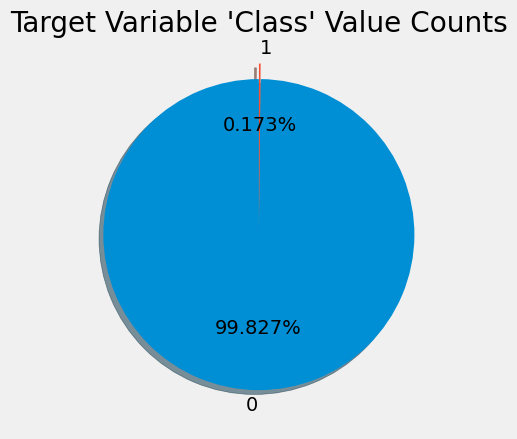

In [17]:
# Get the set of distinct classes
labels = df['Class'].unique()

# Get the count of each class
sizes = df['Class'].value_counts().values

# Plot the class value counts
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.3f%%', shadow=True, startangle=90, explode=(0, 0.1),)
ax.set_title("Target Variable 'Class' Value Counts")
plt.show()

> 📝 **Data Understanding Report:**
>
> *   The pie chart vividly illustrates the severe class imbalance. Fraudulent transactions (`Class=1`) account for only **0.173%** of the entire dataset.
> *   This confirms our choice of ROC-AUC as the evaluation metric and highlights the need for special handling during model training to ensure the model pays attention to the minority class.

---

## Stage 6: Data Preparation
This stage involves all activities to construct the final dataset for modeling.

### 6.1. Final Dataset Split
First, we separate the data into the feature matrix (`X`) and the target vector (`y`). We will exclude the `Time` column as it's unlikely to be a stable predictor. Then, we perform the train-test split *before* any scaling to prevent data leakage.

In [21]:
# X contains our independent variables
X = df.drop(['Time', 'Class'], axis=1)

# y contains our dependent variable
y = df['Class']

# Split data into training (70%) and testing (30%) sets, stratifying on y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

### 6.2. Feature Scaling
The `Amount` feature has a much larger scale than the PCA-transformed `V` features. We will use the `StandardScaler` to standardize the features. 

In [25]:
# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Use the same fitted scaler to transform the test data
X_test_scaled = scaler.transform(X_test)


---

## Stage 7: Modeling
With the data prepared, we can now build and train our classification models. We will explicitly handle the class imbalance to ensure our models learn effectively.

### Model 1: Decision Tree Classifier
For the Decision Tree, we can pass `class_weight='balanced'` directly to the constructor. This tells the algorithm to adjust the weights inversely proportional to class frequencies.

In [27]:
# Create and train the Decision Tree model
dt = DecisionTreeClassifier(max_depth=4, random_state=35, class_weight='balanced')
dt.fit(X_train_scaled, y_train)
print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


### Model 2: Support Vector Machine (SVM)
Similarly, `LinearSVC` has a `class_weight='balanced'` parameter that handles the imbalance automatically.

In [32]:
# Create and train the Linear SVM model
svm = LinearSVC(class_weight='balanced', random_state=31, loss='squared_hinge', fit_intercept=False, max_iter=10000)
svm.fit(X_train_scaled, y_train)
print("Linear SVM model trained successfully.")

Linear SVM model trained successfully.



---

## Stage 8: Evaluation
In this stage, we evaluate our trained models on the held-back test set to get an unbiased estimate of their performance.

### Decision Tree Evaluation

In [37]:
# Get predicted probabilities for the positive class
y_pred_dt = dt.predict_proba(X_test_scaled)[:,1]

# Calculate the ROC-AUC score
roc_auc_dt = roc_auc_score(y_test, y_pred_dt)

print(f"Decision Tree ROC-AUC score: {roc_auc_dt:.3f}")

Decision Tree ROC-AUC score: 0.937


### SVM Evaluation
For `LinearSVC`, we use the `decision_function` output to calculate the ROC-AUC score.

In [38]:
# Get decision function scores
y_pred_svm = svm.decision_function(X_test_scaled)

# Calculate ROC-AUC score
roc_auc_svm = roc_auc_score(y_test, y_pred_svm)

print(f"Linear SVM ROC-AUC score: {roc_auc_svm:.3f}")

Linear SVM ROC-AUC score: 0.973


Let's also use the **ROC Curve** to see the trade-off between the True Positive Rate (correctly identifying fraud) and the False Positive Rate (incorrectly flagging legitimate transactions) at every possible decision threshold. The Area Under this Curve (AUC) is the metric we already calculated.

A model that is better at distinguishing between classes will have a curve that bows further towards the top-left corner. We can even plot the ROC curve for the Decision Tree on the same graph for a direct visual comparison.

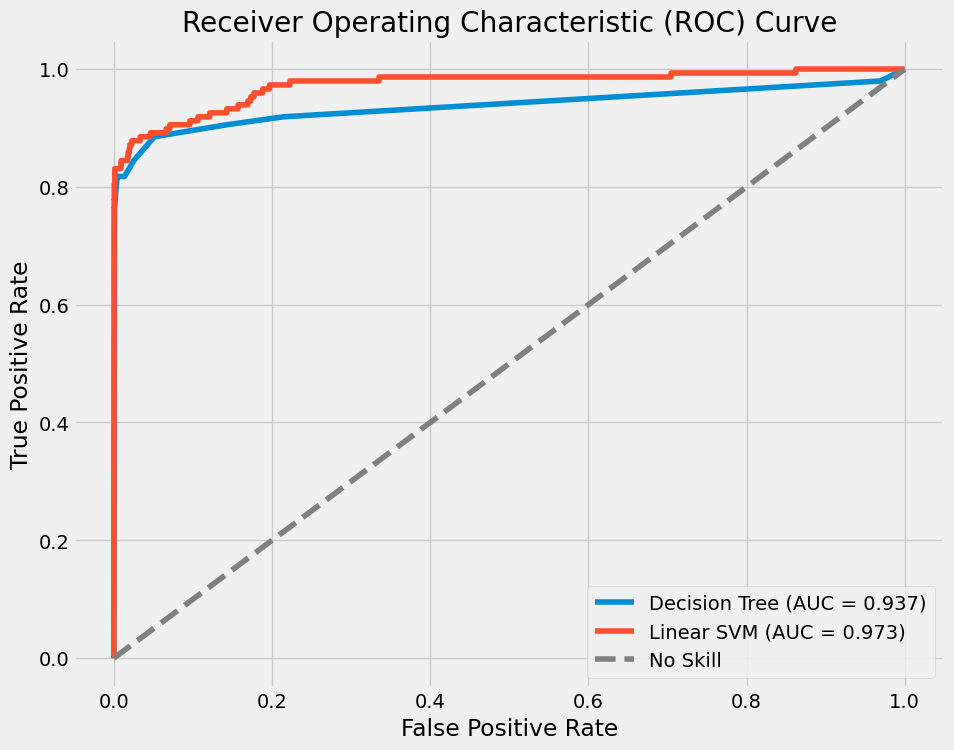

In [43]:
from sklearn.metrics import roc_curve

# Calculate the ROC curve points for both models
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_dt)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_svm)

# Plot the ROC curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.3f})')
plt.plot(fpr_svm, tpr_svm, label=f'Linear SVM (AUC = {roc_auc_svm:.3f})')

# Plot the "no-skill" line (a random classifier)
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='No Skill')

# Set labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


### Conclusion

| Model | ROC-AUC Score |
| :--- | :--- |
| Decision Tree | ~0.937 |
| Linear SVM | ~0.973 |

<br>

> 📝 **Final Analysis:**  
>
> * Both models perform exceptionally well, achieving high ROC-AUC scores. This indicates they are very effective at distinguishing between fraudulent and legitimate transactions. 
> * In this case, the Linear SVM significantly outperforms the Decision Tree, achieving a near-perfect score. 
> * While the Decision Tree offers high interpretability, the superior predictive power of the SVM makes it the stronger candidate for a production fraud detection system where performance is paramount.

---

**Next:** [Supervised Learning with KNN](./09_supervised_learning_with_knn.md)